# Run `run_5d_ac.py` on Apple MPS

Run the first code cell before importing `torch`, `numpy`, or `matplotlib`. It sets the OpenMP/MPS environment variables early enough for this notebook kernel.

In [1]:
import os
import sys
from pathlib import Path

# Must be set before importing torch/numpy/matplotlib in this kernel.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
if not (project_dir / "run_5d_ac.py").exists():
    project_dir = Path("/Users/mengwei/Desktop/DTB_rep/DTB_rep")

os.chdir(project_dir)
sys.path.insert(0, str(project_dir))
print(f"Working directory: {project_dir}")

Working directory: /Users/mengwei/Desktop/DTB_rep/DTB_rep


In [2]:
import torch

print("torch:", torch.__version__)
print("mps built:", torch.backends.mps.is_built())
print("mps available:", torch.backends.mps.is_available())
print("selected:", "mps" if torch.backends.mps.is_available() else "cpu")

torch: 2.12.1
mps built: True
mps available: True
selected: mps


## Smoke Run

This is intentionally smaller than the paper-scale run. Increase `N`, `m`, `chunk`, and fitting settings gradually after this finishes.

In [3]:
%run run_5d_ac.py --T 0.2 --L 10 --N 1000 --m 512 \
                    --width 128 --rank 16 --depth 4 \
                    --fit_steps 300 --fit_samples 2000 \
                    --fit_batch 512 --chunk 250 \
                    --device mps --tag mps_smoke

device: mps   dtype: torch.float32
K=20 steps, L=10, n_blocks=2
trainable params: 6521
=== initial fit to IC ===
initial-fit RMSE = 2.641e-02
block  1/2  t= 0.10  avg DTB residual=2.889e-02  reset RMSE=1.276e-02  (3.0s)
block  2/2  t= 0.20  avg DTB residual=2.545e-02  reset RMSE=1.021e-02  (2.9s)
=== done in 0.1 min ===
snapshots in snapshots/run_mps_smoke


## Inspect Logs

In [4]:
import json
import matplotlib.pyplot as plt
import torch
from pathlib import Path

run_dir = Path("snapshots/run_mps_smoke")
print("run_dir:", run_dir.resolve())
print("files:", sorted(p.name for p in run_dir.glob("*")))

with open(run_dir / "args.json") as fh:
    args = json.load(fh)
print(args)

log = torch.load(run_dir / "log.pt", map_location="cpu", weights_only=False)
for key in ["t", "u_max", "u_rms", "resid", "alpha_norm", "s_norm"]:
    print(key, log[key][-3:] if log[key] else [])

run_dir: /Users/mengwei/Desktop/DTB_rep/DTB_rep/snapshots/run_mps_smoke
files: ['args.json', 'log.pt', 'log_partial.pt', 'meta.pt', 'mps_smoke.png', 'theta_t000.pt', 'theta_t010.pt', 'theta_t020.pt']
{'T': 0.2, 'h': 0.01, 'L': 10, 'nu': 0.01, 'N': 1000, 'm': 512, 'chunk': 250, 'mps_cache_clear_every': 1, 'width': 128, 'rank': 16, 'depth': 4, 'k_per_dim': 40, 'activation': 'gelu', 'fit_steps': 300, 'fit_lr': 0.005, 'fit_batch': 512, 'fit_samples': 2000, 'solver': 'lstsq', 'rtol': 1e-08, 'seed': 0, 'device': 'mps', 'tag': 'mps_smoke', 'snap_dir': 'snapshots', 'verbose_fit': False, 'diag': False, 'log_svdvals': False}
t [0.18, 0.19, 0.2]
u_max [0.7927090525627136, 0.8544096946716309, 0.8395169377326965]
u_rms [0.3828698396682739, 0.38162291049957275, 0.37740185856819153]
resid [0.023110073401059708, 0.02516684721286693, 0.025523797406203114]
alpha_norm [17.85274314880371, 18.916088104248047, 16.996150970458984]
s_norm [102.67277526855469, 117.22826385498047, 130.96188354492188]


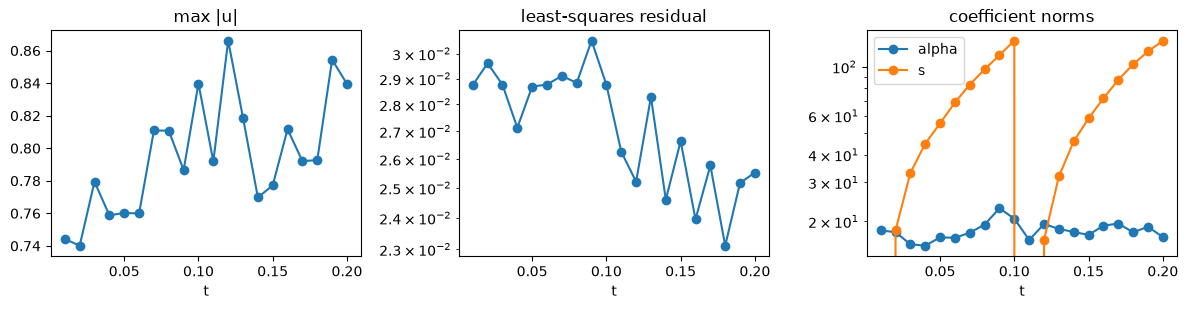

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(log["t"], log["u_max"], marker="o")
axes[0].set_title("max |u|")
axes[0].set_xlabel("t")

axes[1].plot(log["t"], log["resid"], marker="o")
axes[1].set_yscale("log")
axes[1].set_title("least-squares residual")
axes[1].set_xlabel("t")

axes[2].plot(log["t"], log["alpha_norm"], marker="o", label="alpha")
axes[2].plot(log["t"], log["s_norm"], marker="o", label="s")
axes[2].set_yscale("log")
axes[2].set_title("coefficient norms")
axes[2].set_xlabel("t")
axes[2].legend()

fig.tight_layout()

## Optional Visualization

The smoke run saves `t=0.0`, `t=0.1`, and `t=0.2`, so this visualization asks for those times instead of the full paper timeline.

saved snapshots/run_mps_smoke/mps_smoke.png


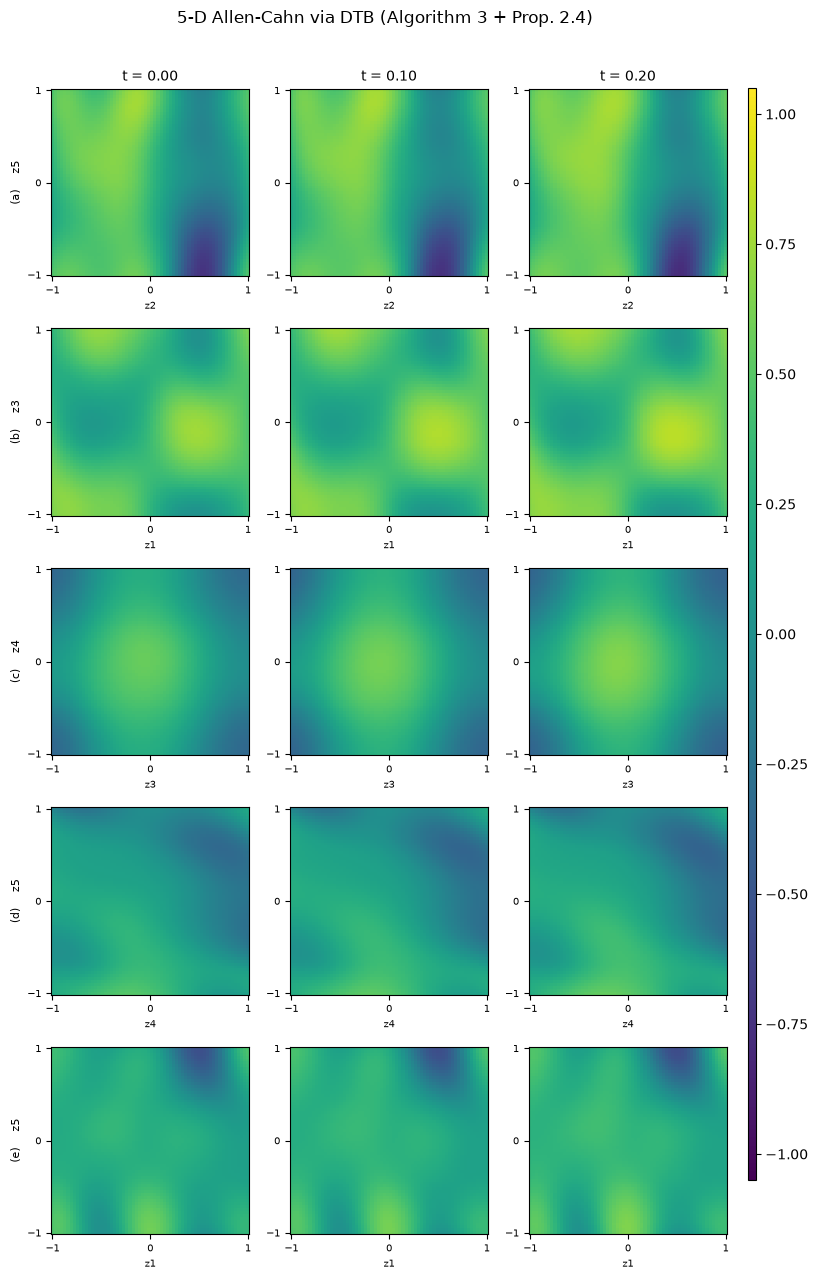

In [6]:
%run visualize.py snapshots/run_mps_smoke --n 64 --times 0.0 0.1 0.2 --out mps_smoke.png

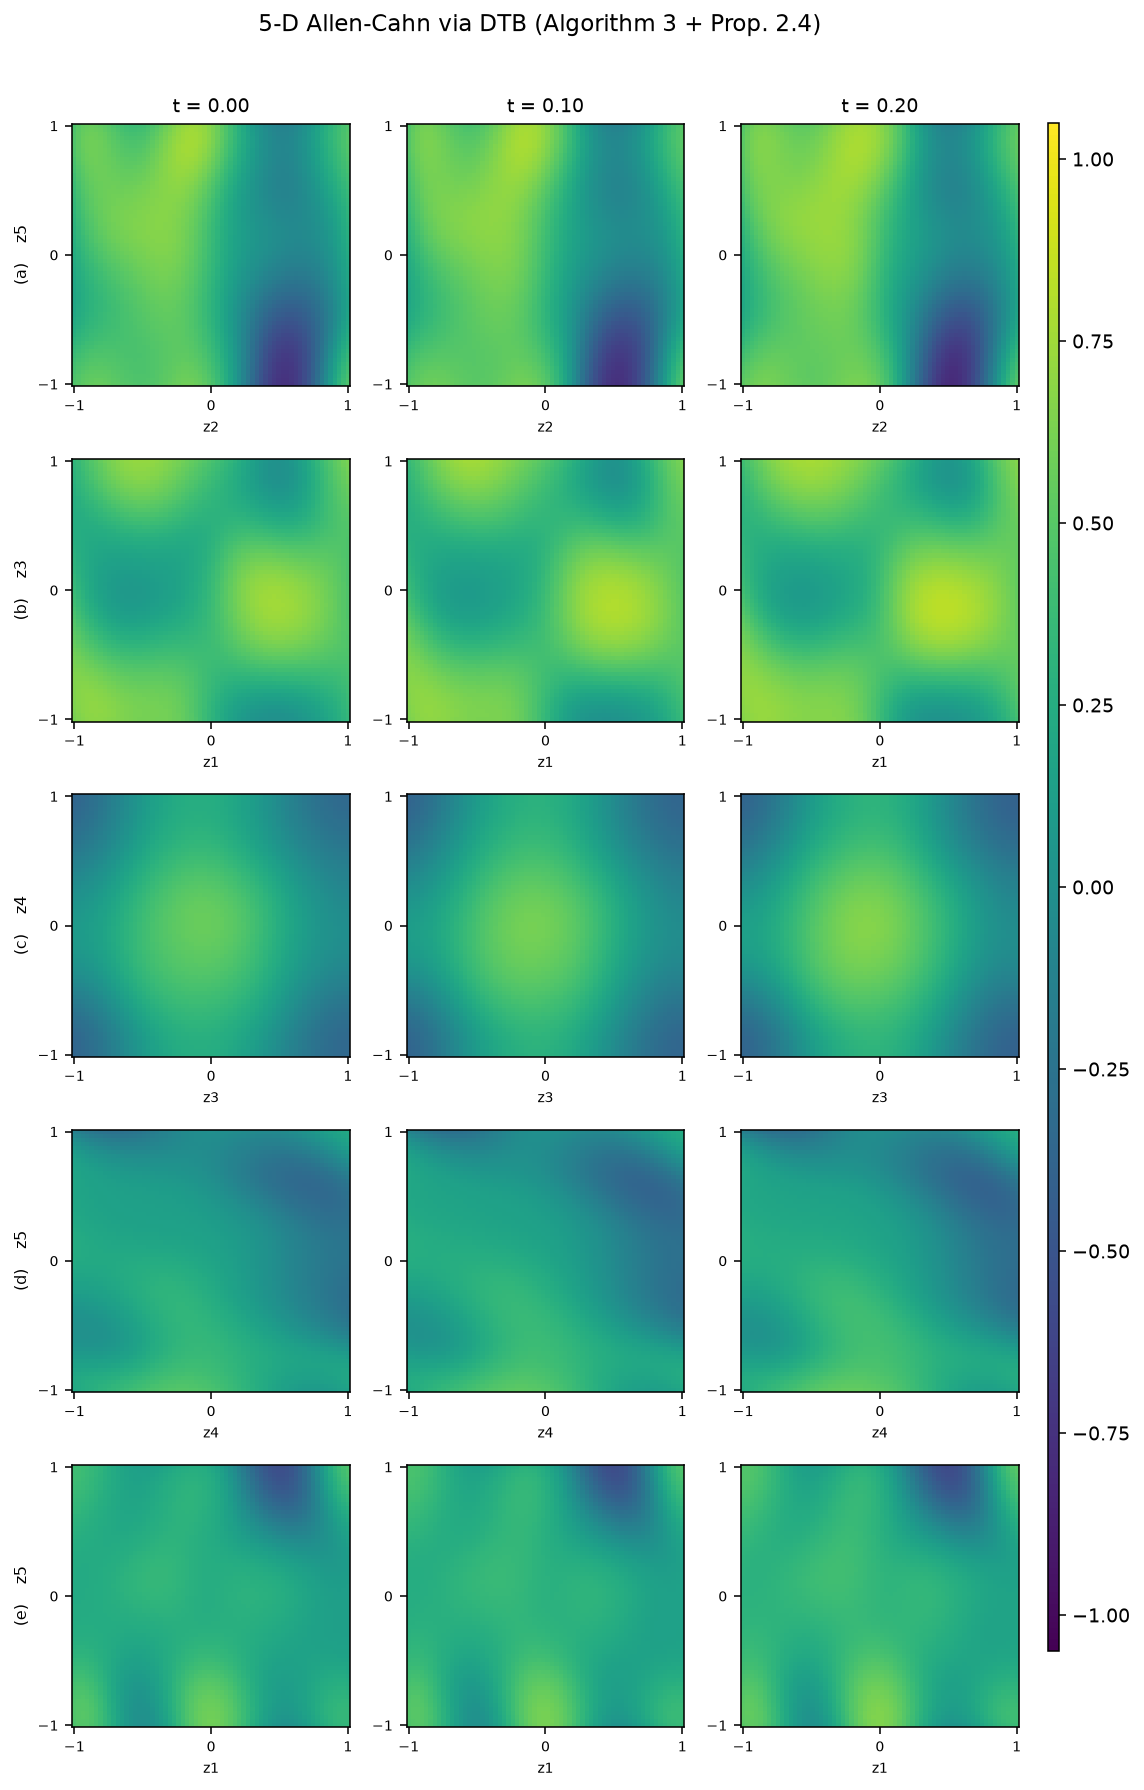

In [7]:
from IPython.display import Image, display

display(Image(filename="snapshots/run_mps_smoke/mps_smoke.png"))

## Paper-Scale First-Step Timing Probe

Run this before the full reproduction if you want a time estimate on this Mac. It uses the paper architecture but lets you choose smaller `probe_N` and `probe_m`. The full run has 200 DTB steps plus 10 reset fits; if this probe is already very slow, the full laptop run will be a many-hour job.


In [8]:
import time
import torch

from network import PeriodicMMNN, count_trainable
from dtb import device, flat_params, dtb_basis_matrices, empty_cache

probe_N = 2000
probe_m = 1000
probe_chunk = 50
probe_mps_cache_clear_every = 10
probe_dev = device("mps")
probe_dtype = torch.float32

torch.manual_seed(0)
probe_model = PeriodicMMNN(
    dim_in=5, k_per_dim=40, width=366, rank=25, depth=7,
    activation="gelu", dtype=probe_dtype,
).to(probe_dev)
probe_M = count_trainable(probe_model)
probe_theta, probe_structure, _ = flat_params(probe_model)
probe_theta = probe_theta.to(probe_dev)
probe_sel = torch.randperm(probe_M, device=probe_dev)[:probe_m].sort().values
probe_z = torch.rand(probe_N, 5, dtype=probe_dtype, device=probe_dev) * 2.0 - 1.0

empty_cache(probe_dev)
t0 = time.time()
_ = dtb_basis_matrices(probe_theta, probe_sel, probe_z, probe_model, probe_structure,
    chunk=probe_chunk,
    mps_cache_clear_every=probe_mps_cache_clear_every,
)
elapsed = time.time() - t0
print(f"probe N={probe_N}, m={probe_m}, chunk={probe_chunk}, cache_every={probe_mps_cache_clear_every}: {elapsed:.1f}s")
print("very rough full-step scale factor:", (20000 / probe_N) * (6000 / probe_m))
print("rough full-step estimate:", elapsed * (20000 / probe_N) * (6000 / probe_m) / 60, "minutes")

del probe_model, probe_theta, probe_sel, probe_z, _
empty_cache(probe_dev)


probe N=2000, m=1000, chunk=50, cache_every=10: 1.0s
very rough full-step scale factor: 60.0
rough full-step estimate: 0.9931590557098389 minutes


## Full Paper-Scale DTB Reproduction

This uses the setup from `summary.tex`: `T=2.0`, `h=0.01`, `L=20`, `N=20000`, `m=6000`, MMNN `(width=366, rank=25, depth=7)`, `fit_steps=6000`, `fit_lr=3e-3`, and `fit_samples=20000`. The output tag is `paper_mps` so it will not overwrite the existing CUDA runs.

On Apple Silicon this can take much longer than the RTX timing in the summary because the dense least-squares solve falls back to CPU float32. This cell launches a fresh Python subprocess instead of `%run`, which avoids keeping smoke-test tensors and MPS cache in the notebook kernel. `--chunk 50` only changes memory batching, not the mathematical setup. `--diag` prints progress at the start of each DTB step and the driver writes `log_partial.pt` after every completed step. `--mps_cache_clear_every 10` avoids the overhead of clearing MPS cache on every tiny chunk; if you hit OOM, set it back to `1`.


In [ ]:
import os
import subprocess
import sys

paper_cmd = [
    sys.executable, "-u", "run_5d_ac.py",
    "--T", "2.0", "--h", "0.01", "--L", "20",
    "--N", "20000", "--m", "6000",
    "--width", "366", "--rank", "25", "--depth", "7", "--k_per_dim", "40",
    "--activation", "gelu",
    "--fit_steps", "6000", "--fit_lr", "3e-3",
    "--fit_samples", "20000", "--fit_batch", "4000",
    "--chunk", "50", "--mps_cache_clear_every", "10",
    "--solver", "lstsq", "--rtol", "1e-8",
    "--seed", "0", "--device", "mps", "--tag", "paper_mps", "--diag",
]

paper_env = os.environ.copy()
paper_env.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
paper_env.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
paper_env.setdefault("OMP_NUM_THREADS", "1")

proc = subprocess.Popen(
    paper_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=paper_env,
)
for line in proc.stdout:
    print(line, end="")
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"paper run failed with exit code {ret}")


device: mps   dtype: torch.float32
K=200 steps, L=20, n_blocks=10
trainable params: 55617
=== initial fit to IC ===
initial-fit RMSE = 3.051e-03
  block  1/10  step   1/20: building DTB basis...
  step   0/20  |u_k| max=8.382e-01  |alpha|=3.344e+02  |s|=0.000e+00  |J|=2.106e+02  |g|=3.339e+01  resid=4.593e-03  wall=17.9s
  block  1/10  step   2/20: building DTB basis...
  block  1/10  step   3/20: building DTB basis...
  block  1/10  step   4/20: building DTB basis...
  block  1/10  step   5/20: building DTB basis...
  step   4/20  |u_k| max=8.409e-01  |alpha|=3.290e+02  |s|=1.154e+03  |J|=2.097e+02  |g|=3.381e+01  resid=4.614e-03  wall=20.9s
  block  1/10  step   6/20: building DTB basis...
  block  1/10  step   7/20: building DTB basis...
  block  1/10  step   8/20: building DTB basis...
  block  1/10  step   9/20: building DTB basis...
  step   8/20  |u_k| max=8.371e-01  |alpha|=3.184e+02  |s|=2.157e+03  |J|=2.103e+02  |g|=3.438e+01  resid=4.677e-03  wall=21.7s
  block  1/10  step  

## Paper-Scale Diagnostics

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import torch

paper_run_dir = Path("snapshots/run_paper_mps")
print("run_dir:", paper_run_dir.resolve())
print("snapshots:", sorted(p.name for p in paper_run_dir.glob("theta_t*.pt")))

with open(paper_run_dir / "args.json") as fh:
    paper_args = json.load(fh)
print(paper_args)

paper_log = torch.load(paper_run_dir / "log.pt", map_location="cpu", weights_only=False)

block_count = max(paper_log["block"]) if paper_log["block"] else 0
for block in range(1, block_count + 1):
    idx = [i for i, b in enumerate(paper_log["block"]) if b == block]
    avg_resid = sum(paper_log["resid"][i] for i in idx) / len(idx)
    t_end = paper_log["t"][idx[-1]]
    print(f"block {block:2d}  t={t_end:4.2f}  avg residual={avg_resid:.3e}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(paper_log["t"], paper_log["u_max"])
axes[0].set_title("paper run: max |u|")
axes[0].set_xlabel("t")

axes[1].plot(paper_log["t"], paper_log["resid"])
axes[1].set_yscale("log")
axes[1].set_title("paper run: residual")
axes[1].set_xlabel("t")

axes[2].plot(paper_log["t"], paper_log["alpha_norm"], label="alpha")
axes[2].plot(paper_log["t"], paper_log["s_norm"], label="s")
axes[2].set_yscale("log")
axes[2].set_title("paper run: coefficient norms")
axes[2].set_xlabel("t")
axes[2].legend()
fig.tight_layout()

## Render Figure 5 Panels

In [ ]:
%run visualize.py snapshots/run_paper_mps --n 120 --times 0.0 0.4 0.8 1.2 1.6 2.0 --out figure5_5d_ac_mps.png

In [ ]:
from IPython.display import Image, display

display(Image(filename="snapshots/run_paper_mps/figure5_5d_ac_mps.png"))

## Optional: Compare Against Saved Paper Figure Rows

This uses the `paper_figures/x13.png` ... `x17.png` files already in the repo and writes one comparison PNG per hyperplane into `snapshots/run_paper_mps/`.

In [ ]:
%run compare_to_paper.py snapshots/run_paper_mps --paper_dir paper_figures --n 160

In [ ]:
from IPython.display import Image, display

for name in ["a", "b", "c", "d", "e"]:
    display(Image(filename=f"snapshots/run_paper_mps/cmp_hyperplane_{name}.png"))